# ```Seminar 3: DUSt3R ```

## Theory

### CroCo

CroCo(Cross-View Completion) is a self-supervised training objective specially designed to learn 3D geometry
from unlabeled data. Given two images depicting
the same scene, random parts of the first input image are masked and then predicted by the model using:

- the visible parts of this first image
- a second image called reference
image as it depicts the same scene from a different point of view.

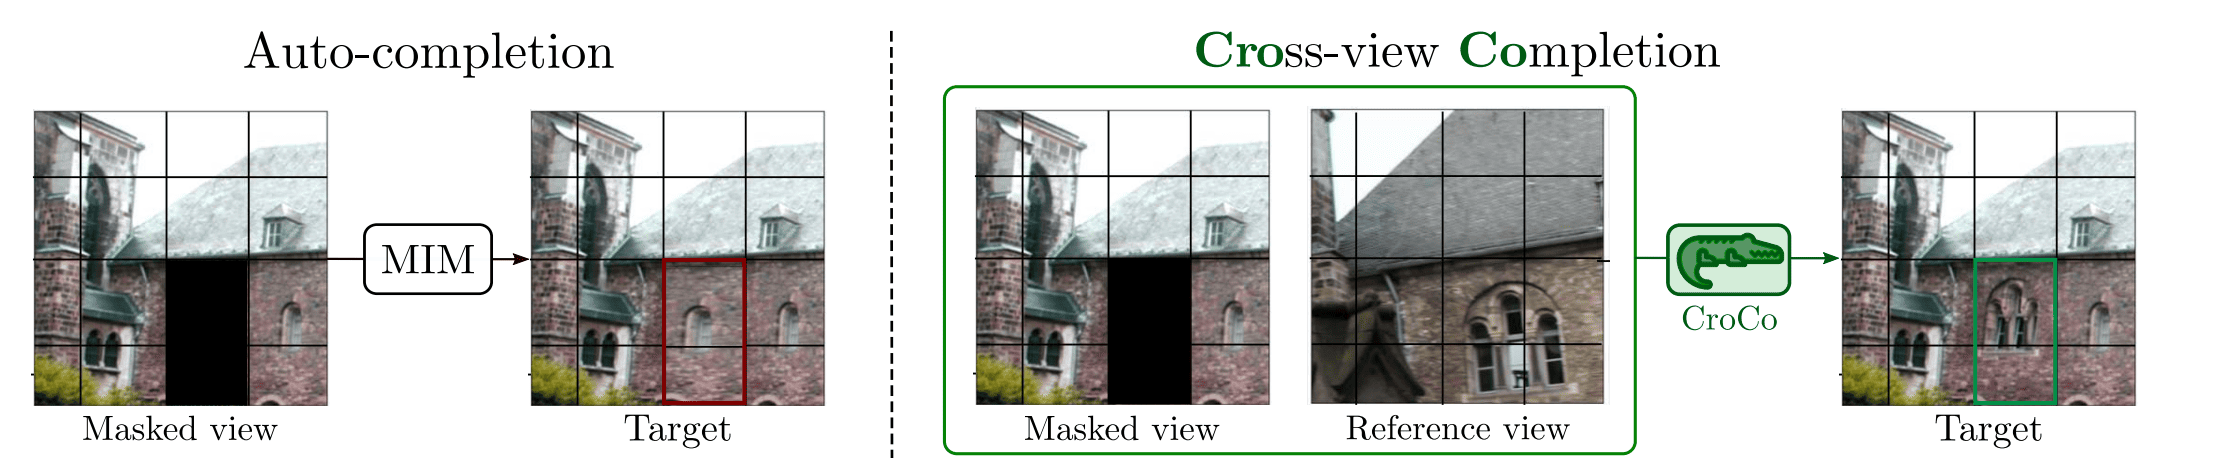

***CroCo architecture.***  Let $\mathbf{x}_1$ and $\mathbf{x}_2$ be two images of the same scene taken from different viewpoints. Both images are divided into $N$ non-overlapping patches $p_1 = \{p_1^1, \dots, p_1^N\}$, $p_2 = \{p_2^1, \dots, p_2^N\}$, and a number $n = \lfloor rN \rfloor$ of tokens from the first set $p_1$ is randomly masked, with $r \in [0,1]$ being a masking ratio hyper-parameter. Typically $r = 0.9$ is used. We denote the remaining set of visible patches from the first image by $\widetilde{p}_1 = \{p_1^i \mid m_i = 0\}$, with $m_i = 0$ indicating that the patch $p_1^i$ is not masked ($m_i = 1$ otherwise).

An encoder $\varepsilon_\theta$ processes $\widetilde{p}_1$ and $p_2$ independently, and a decoder $D_\phi$ takes the encoding $\varepsilon_\theta(\widetilde{p}_1)$, conditioned on encoding $\varepsilon_\theta(p_2)$, in order to reconstruct $p_1$:

\begin{equation}
    \hat{p}_1 = D_\phi \left( \varepsilon_\theta(\widetilde{p}_1); \varepsilon_\theta(p_2) \right).
\end{equation}


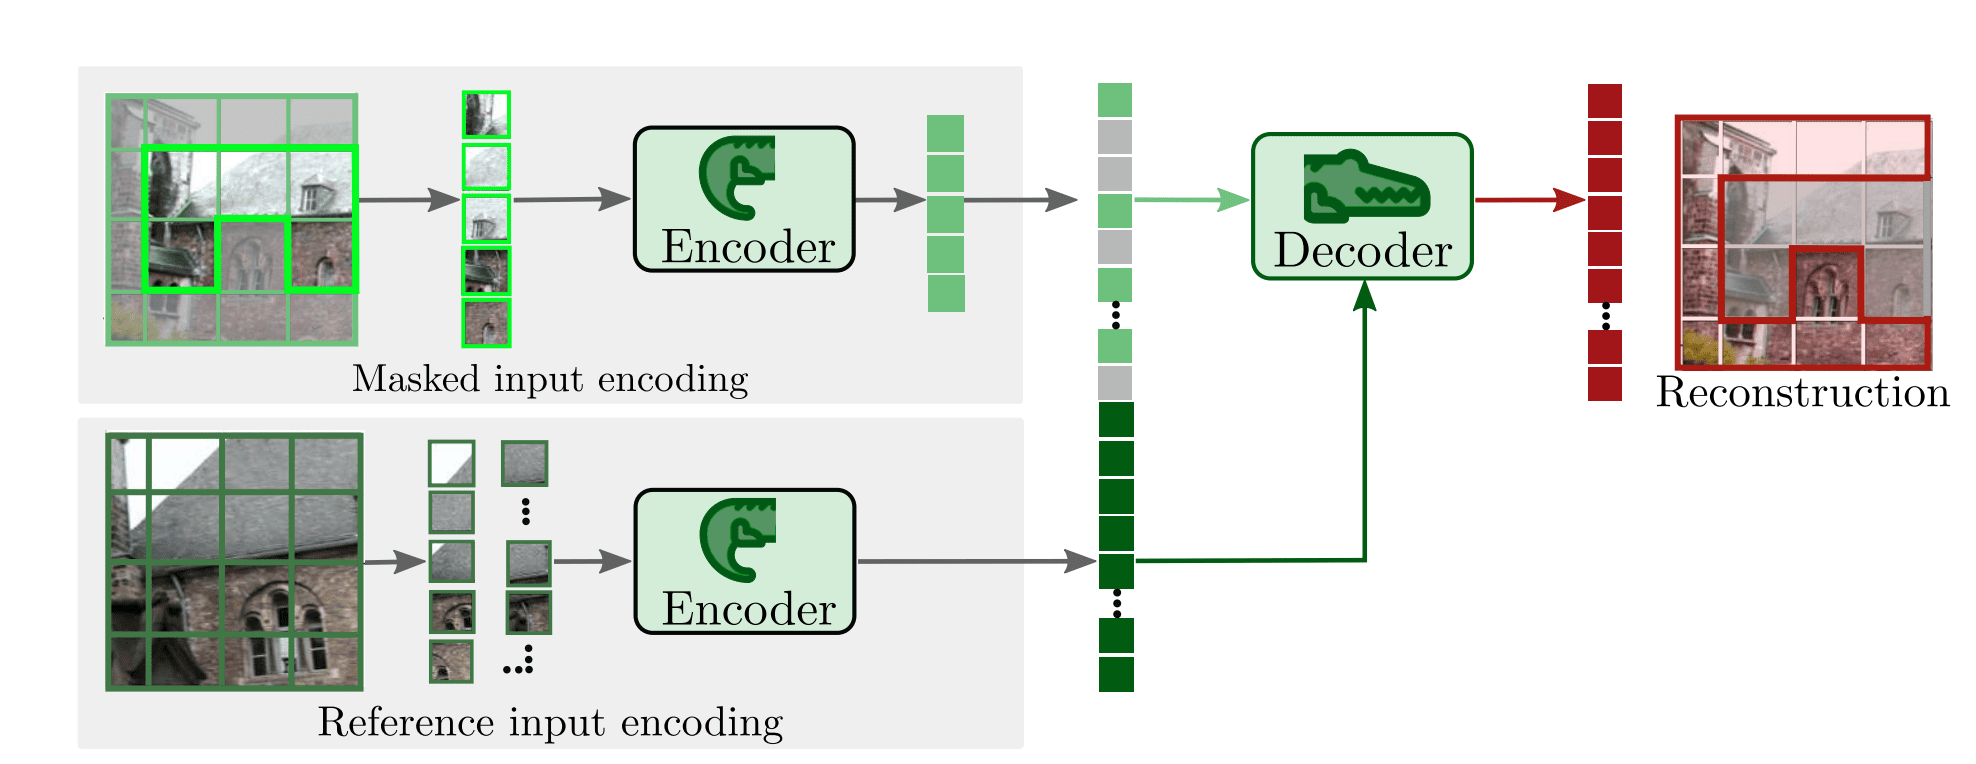

***The encoder $\varepsilon_\theta$*** used in CroCo is a standard Vision Transformer (ViT), which processes image patches to produce spatially-aware feature representations.

***The decoder $D_{\phi}$*** with weights $\phi$ takes as input the set of encoded tokens
from the first image $ \varepsilon_\theta(\widetilde{p}_1)$ concatenated with a learned representation $e_{\text{mask}}$ that is repeated $n$ times to account for the masked patches. These tokens are iteratively processed by an attention-based block that also takes into account the encoded tokens $ \varepsilon_\theta(p_2)$ from the reference image $\mathbf{x}_2$. A sinusoidal positional encoding is added to all tokens before being decoded by $D_{\phi}$.


There are two different architectures for the decoder block. The first one, termed *CrossBlock*, consists of:


1.   multi-head self-attention on the tokens representing the first image
2.   multi-head cross-attention between these tokens and the tokens
in $ \varepsilon_\theta(p_2)$ from the reference image

3.  MLP layer

The second architecture, termed *CatBlock*,
proceeds by concatenating the tokens from the two images, with an added learnable embedding for each of the two images, and then feeding these tokens to a series of standard transformer blocks:

1. multi-head self-attention

2. MLP layer

Only the subset of tokens
corresponding to the first image is taken into account for the final prediction. These two attention
blocks represent a trade-off between model size and computational cost. Indeed, *CrossBlock* has more learnable parameters, due to the cross-attention module, but a lower computational cost as it
avoids the quadratic complexity of computing self-attention over the joint token set of size $2N$. Authors choose *CrossBlock* as main architecture component.







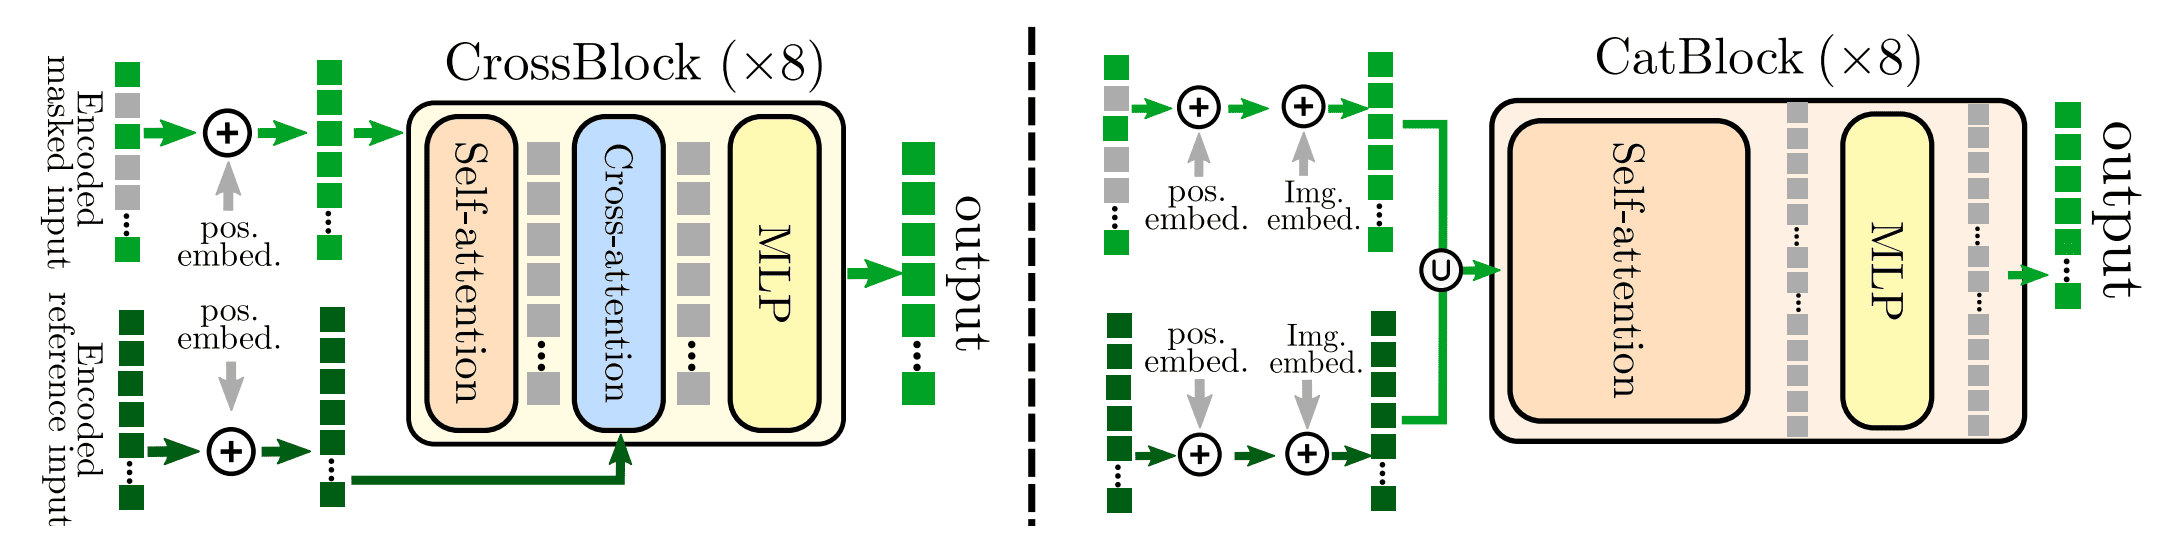

***Training the CroCo model.*** The decoder produces one feature vector per patch token, which is processed by a fully-connected layer that outputs 3 values (R, G and B) per pixel for each patch. These outputs serve as predicted reconstruction $\hat{p}_1$, evaluated using MSE loss between predictions and ground-truth values of the pixels, averaged over the set of all masked tokens, denoted $p_1 \setminus \tilde{p}_1$. Thus to perform self-supervised pre-training, the network is trained to minimize:

\begin{equation}
L(x_1, x_2) = \frac{1}{|p_1 \setminus \tilde{p}_1|} \sum_{p_1^i \in p_1 \setminus \tilde{p}_1} \| \hat{p_1^i} - p_1^i \|^2.
\end{equation}


### DUSt3R

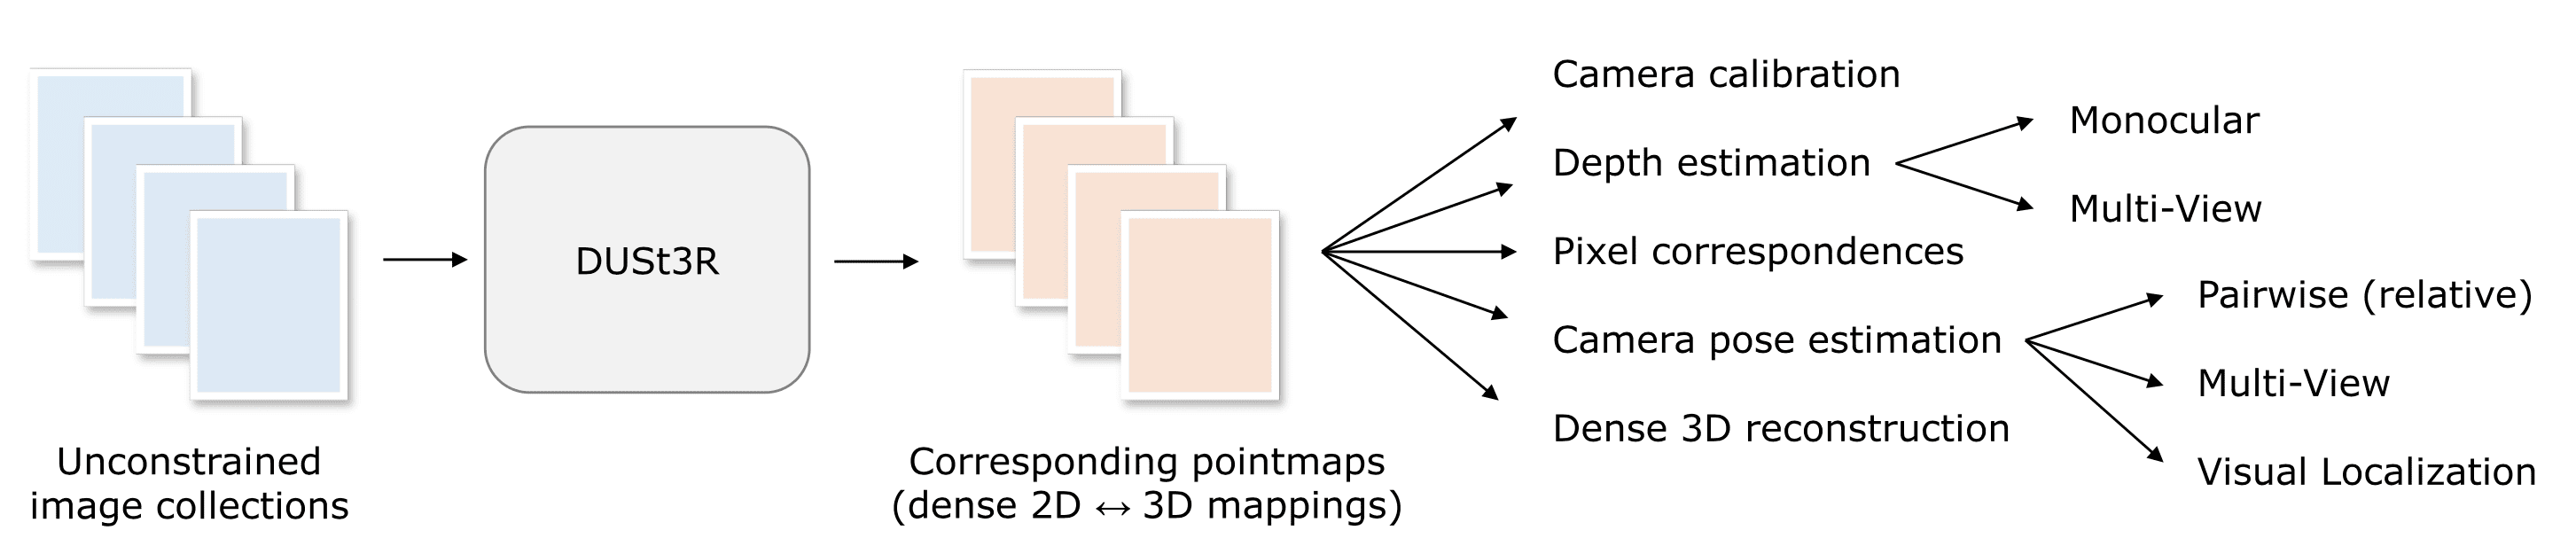

Traditional Multi-View Stereo (MVS) methods rely heavily on camera intrinsic and extrinsic parameters which are often difficult to obtain. DUSt3R introduces a fundamentally different approach to dense 3D reconstruction from image collections by eliminating the need for camera calibration or pose estimation. Instead of explicitly modeling projective geometry, DUSt3R predicts dense 3D pointmaps for each image, which serve as continuous representations of the scene geometry. Built on top of standard Transformer architectures and leveraging pretrained CroCo backbones, DUSt3R produces high-quality 3D reconstructions, depth maps, and pixel-level correspondences. Moreover, it enables relative and absolute camera pose estimation — all within a single framework.

We have an RGB image $I \in \mathbb{R}^{H \times W \times 3}$ of resolution $W \times H$.

***Pointmap***  $X \in \mathbb{R}^{H \times W \times 3}$ is a dense 2D field of 3D points. $X$ forms a one-to-one mapping between image pixels and 3D scene points:

 $$I_{i,j} \leftrightarrow X_{i,j} \quad \forall (i, j) \in \{1, \ldots, W\} \times \{1, \ldots, H\}$$

 $I_{i, j}$ is a colour, and $X_{i, j}$ denotes $(x, y, z)$ point in a 3D space. We assume here that *each camera ray hits a single 3D point*, i.e. ignoring the case of translucent surfaces.


***Cameras and scene.***

Given the camera intrinsics

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1  \end{bmatrix} \in \mathbb{R}^{3 \times 3},$$


 the pointmap $X$ of the observed scene can be straightforwardly obtained from the ground-truth depthmap $D \in \mathbb{R}^{W \times H}$ as

$$X_{i,j} = \begin{bmatrix} x \\ y \\ z \end{bmatrix} = K^{−1} \begin{bmatrix} iD_{i,j} \\ jD_{i,j} \\ D_{i,j} \end{bmatrix}.$$

Here, $X$ is expressed in the camera coordinate frame.

In the following, *we **denote as $X^{n,m}$** the pointmap $X^n$ from camera $n$ expressed in camera $m$’s coordinate frame*:

$$X^{n, m} = P_m \ P_n^{-1}h(X^n)$$

with $P_m, P_n \in \mathbb{R}^{3 \times 4}$ the world-to-camera poses for images $n$ and $m$, and $h: (x, y, z) \to (x, y, z, 1)$ the homogeneous mapping.

#### Network architecture

We wish to build a network that solves the 3D reconstruction
task for the generalized stereo case through direct regression.
To that aim, we train a network $F$ that takes as input two RGB
images $I^1, I^2 \in \mathbb{R}^{W \times H \times 3 }$ and outputs two corresponding pointmaps $X^{1, 1}, X^{2, 1} \in \mathbb{R}^{W \times H \times 3 }$ with associated confidence maps $C^{1, 1}, C^{2, 1} \in \mathbb{R}^{W \times H}$. For the sake of clarity and without loss of generalization, we assume that
both images have the same resolution $W \times H$, but naturally
in practice their resolution can differ.

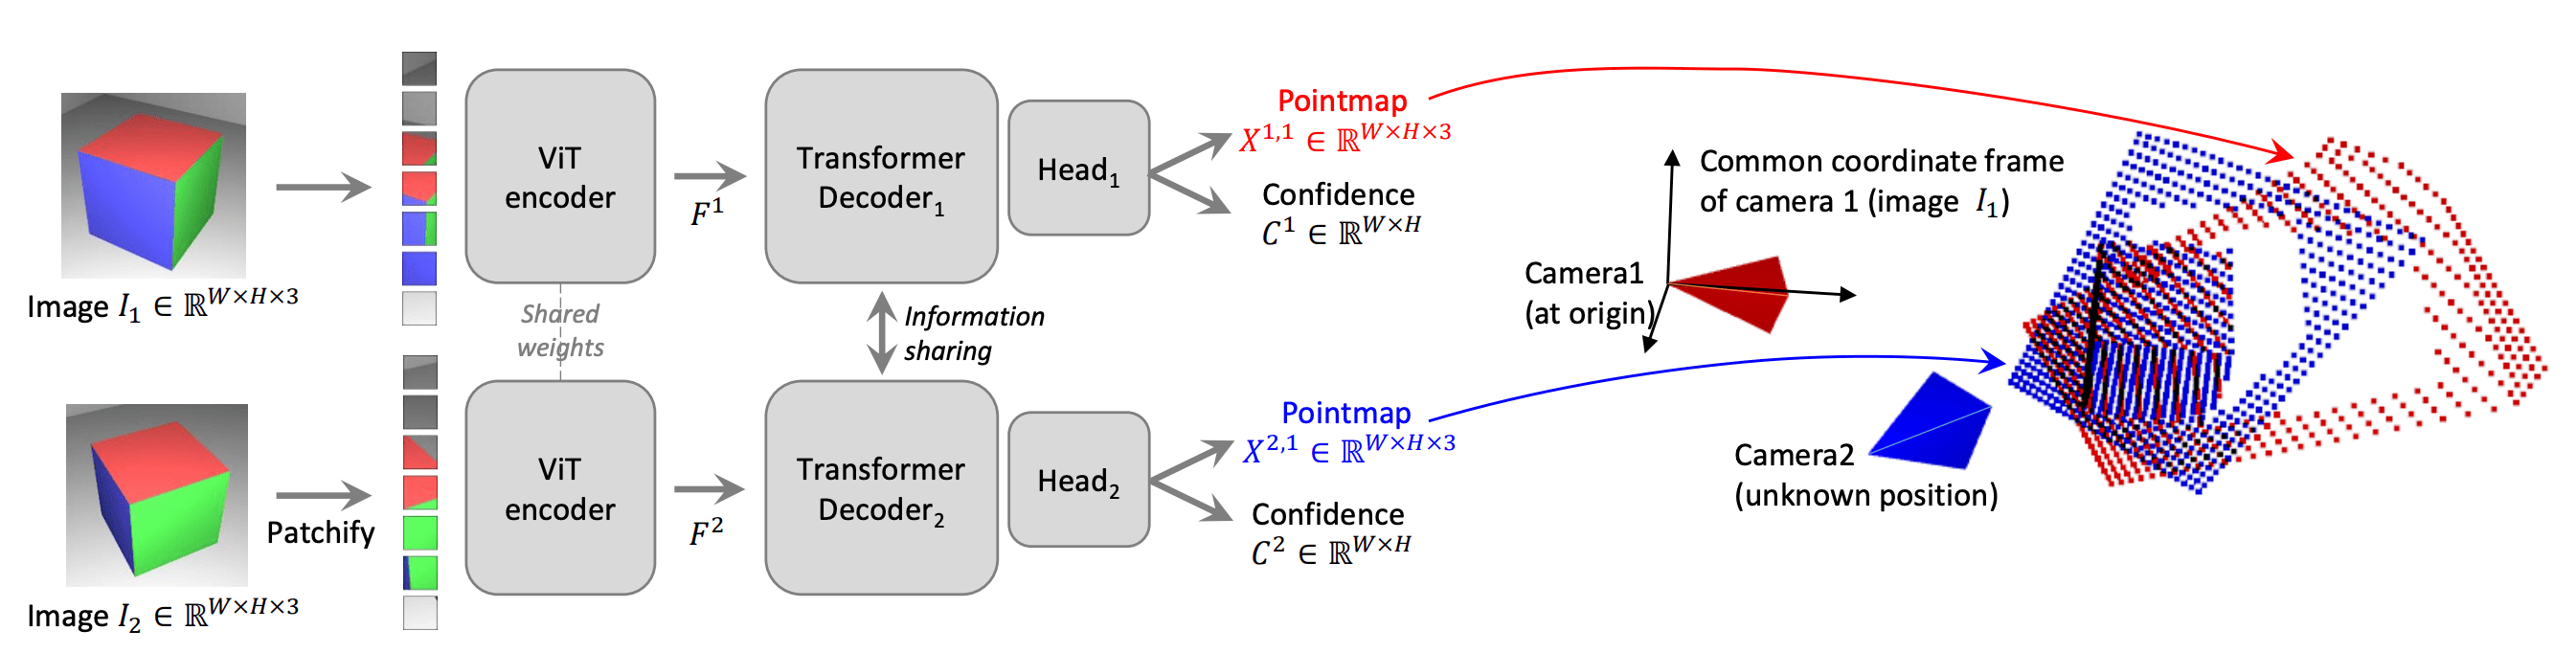

The architecture of network F
is composed of two identical branches (one for each
image) comprising each an image encoder, a decoder and
a regression head. The two input images are first encoded
in a Siamese manner by the same weight-sharing ViT encoder, yielding two token representations $F^1$ and $F^2$:

$$
\begin{align}
F^1 = \text{Encoder}(I^1) \\
F^2 = \text{Encoder}(I^2)
\end{align}
$$

The network then reasons over both of them jointly in the
decoder. Similarly to CroCo, the decoder is a generic
transformer network equipped with cross attention. Each decoder block thus sequentially performs self-attention, then
cross-attention, and finally feeds tokens to a MLP.
Importantly, information is constantly shared between the
two branches during the decoder pass:


$$
\begin{align}
G_i^{1} = \text{DecoderBlock}_i^1(G_{i - 1}^1, G_{i - 1}^2)  \\
G_i^{2} = \text{DecoderBlock}_i^2(G_{i - 1}^2, G_{i - 1}^1)
\end{align}
$$

for $i = 1, \ldots , B \ $ for a decoder with $B$ blocks and initialized with encoder tokens $G^1_0 := F^1$ and $G^2_0 := F^2$. Here, $\text{DecoderBlock}^v_i(G^1, G^2)$ denotes the i-th block in branch $v \in \{1, 2\}$, $G^1$ and $G^2$ are the input tokens, with $G^2$ the tokens from the other branch. Finally, in each branch a separate regression head takes the set of decoder tokens and
outputs a pointmap and an associated confidence map:

$$
\begin{align}
X^{1, 1}, C^{1, 1} = \text{Head}_1(G_{0}^1, \ldots, G_{B}^1)  \\
X^{2, 1}, C^{2, 1} = \text{Head}_2(G_{0}^2, \ldots, G_{B}^2)
\end{align}
$$


### Training Objective

***3D Regression loss.*** Let us denote the groundtruth pointmaps as $\bar{X}^{1,1}$ and $\bar{X}^{2,1}$ along with two corresponding sets of valid pixels $ D^1, D^2 \in \{1, \ldots, W \} \times \{1, \ldots, H \}$ on which the ground-truth is defined.

The regression loss for a valid pixel $ i \in D^v $ in view $ v \in \{1, 2\} $ is simply defined as the Euclidean distance:


\begin{equation}
\ell_{\text{regr}}(v, i) = \left\| \frac{1}{z} X_i^{v,1} - \frac{1}{\bar{z}} \bar{X}_i^{v,1} \right\|.
\end{equation}



To handle the scale ambiguity between prediction and ground-truth, we normalize the predicted and ground-truth pointmaps by scaling factors
$ z = \text{norm}(X^{1,1}, X^{2,1}) $ and $ \bar{z} = \text{norm}(\bar{X}^{1,1}, \bar{X}^{2,1}) $, respectively, which simply represent the average distance of all valid points to the origin:
\begin{equation}
\text{norm}(X^1, X^2) = \frac{1}{|D^1| + |D^2|} \sum_{v \in \{1,2\}} \sum_{i \in D^v} \| X_i^v \|.
\end{equation}

***Confidence-aware loss.*** In reality, and contrary to our assumption, there are ill-defined 3D points, *e.g.*, in the sky or on translucent objects. More generally, some parts in the image are typically harder to predict than others. We thus jointly learn to predict a score for each pixel which represents the confidence that the network has about this particular pixel. The final training objective is the confidence-weighted regression loss over all valid pixels:

$$
L_{\text{conf}} = \sum_{v \in \{1,2\}} \sum_{i \in D^v} C_i^{v,1} \ell_{\text{regr}}(v, i) - \alpha \log C_i^{v,1},
$$

where $ C_i^{v,1} $ is the confidence score for pixel $ i $, and $\alpha $ is a hyper-parameter controlling the regularization term. To ensure a strictly positive confidence, we typically define $ C_i^{v,1} = 1 + \exp \widetilde{C_i^{v,1}} > 1 $.


## Practice

### Installation code

Let's first download our data.

In [1]:
!wget https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_03/seminar/left.jpg
!wget https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_03/seminar/right.jpg

--2026-02-05 07:07:25--  https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_03/seminar/left.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 124500 (122K) [image/jpeg]
Saving to: ‘left.jpg’

left.jpg            100%[===================>] 121.58K  --.-KB/s    in 0.002s  

2026-02-05 07:07:25 (75.9 MB/s) - ‘left.jpg’ saved [124500/124500]

--2026-02-05 07:07:25--  https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_03/seminar/right.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118997 (116K) [image/j

Now we can install dust3r.

In [2]:
import os
from IPython.display import clear_output

# Clone Repo
%cd /content
!git clone --recursive https://github.com/naver/dust3r
%cd /content/dust3r
!git checkout 88a43b939ebced21c069dd9df9e9e463324b7f5f

# Setup Environment
!pip install -r requirements.txt
!pip install -e .

# Download weights
if not os.path.exists('checkpoints'):
    !mkdir -p checkpoints/
    !wget https://download.europe.naverlabs.com/ComputerVision/DUSt3R/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth -P checkpoints/

clear_output()

### Run model

Let's load model from downloaded checkpoint.

In [3]:
import cv2
import torch
import numpy as np
import matplotlib.pylab as plt
from dust3r.model import AsymmetricCroCo3DStereo, inf  # needed when loading the model
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference

np.set_printoptions(precision=3)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


In [4]:
def load_model(model_path, device, verbose=True):
    if verbose:
        print('... loading model from', model_path)
    ckpt = torch.load(model_path, map_location='cpu', weights_only=False)
    args = ckpt['args'].model.replace("ManyAR_PatchEmbed", "PatchEmbedDust3R")
    if 'landscape_only' not in args:
        args = args[:-1] + ', landscape_only=False)'
    else:
        args = args.replace(" ", "").replace('landscape_only=True', 'landscape_only=False')
    assert "landscape_only=False" in args
    if verbose:
        print(f"instantiating : {args}")
    net = eval(args)
    s = net.load_state_dict(ckpt['model'], strict=False)
    if verbose:
        print(s)
    return net.to(device)


model = load_model("/content/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth", device)

... loading model from /content/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
instantiating : AsymmetricCroCo3DStereo(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100', patch_embed_cls='PatchEmbedDust3R', img_size=(512, 512), head_type='dpt', output_mode='pts3d', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), landscape_only=False)
<All keys matched successfully>


In [5]:
!cd /content && ls

dust3r	left.jpg  right.jpg  sample_data


In [6]:
images = load_images(['/content/left.jpg', '/content/right.jpg'], size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=False)

>> Loading a list of 2 images
 - adding /content/left.jpg with resolution 960x1280 --> 384x512
 - adding /content/right.jpg with resolution 960x1280 --> 384x512
 (Found 2 images)


In [7]:
output = inference(pairs, model, device, batch_size=1)
pred1, pred2 = output['pred1'], output['pred2']

>> Inference with model on 1 image pairs


  0%|          | 0/1 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 1/1 [00:02<00:00,  2.03s/it]


In [8]:
img_left, img_right = output['view1']['img'][0].permute(1, 2, 0).cpu().numpy(), output['view2']['img'][0].permute(1, 2, 0).cpu().numpy()
img_left = (img_left + 1.0) / 2.0
img_right = (img_right + 1.0) / 2.0

pred1, pred2 = output['pred1'], output['pred2']

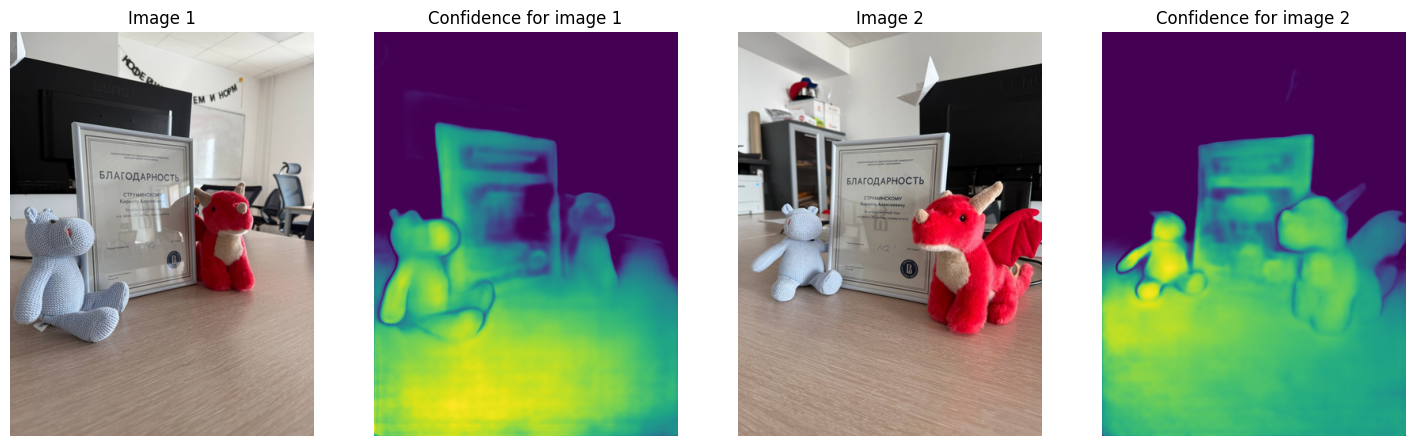

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i in range(2):
    temp_image = output[f'view{i+1}']['img'][0].permute(1, 2, 0).cpu().numpy()
    temp_image = (temp_image + 1.0) / 2.0
    temp_conf = output[f'pred{i+1}']['conf'].permute(1, 2, 0).cpu().numpy()

    axes[i*2].imshow(temp_image)
    axes[i*2+1].imshow(temp_conf)

    axes[i*2].axis('off')
    axes[i*2+1].axis('off')

    axes[i*2].set_title(f"Image {i+1}")
    axes[i*2+1].set_title(f"Confidence for image {i+1}")

plt.show()

### Point matching

Establishing correspondences between pixels of two images can be trivially achieved by nearest neighbor(NN) search in the 3D pointmap space. To minimize errors, we typically retain reciprocal correspondences $M_{1,2}$ between images $I^1$ and $I^2$, i.e. we have:

$$M_{1,2} = \{(i, j) \ | \ i = \text{NN}_1^{1, 2}(j) \ \text{and} \ j = \text{NN}_1^{2, 1}(i) \}$$

$$\text{with} \quad \text{NN}_{k}^{n, m}(i) = \underset{j \in \{ 0, \ldots, WH \} }{argmin}  \ ||X^{n, k}_j - X^{m, k}_i||$$


In [10]:
from sklearn.neighbors import NearestNeighbors

pts1 = pred1['pts3d'][0]
pts2 = pred2['pts3d_in_other_view'][0]
H, W, _ = pts1.shape
N = H * W

# expand to (N, 3)
x1 = pts1.view(N, 3).cpu().numpy()
x2 = pts2.view(N, 3).cpu().numpy()

# using classical NN-model for x2
nn_2 = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(x2)
d1, idx_1_to_2 = nn_2.kneighbors(x1, return_distance=True)
idx_1_to_2 = idx_1_to_2[:,0]

# using classical NN-model for x2
nn_1 = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(x1)
d2, idx_2_to_1 = nn_1.kneighbors(x2, return_distance=True)
idx_2_to_1 = idx_2_to_1[:,0]

# select only mutual pairs: i -> j and j -> i
ids = np.arange(N)
# i -> j -> k, good match if i = k
mask = (idx_2_to_1[idx_1_to_2] == ids)

mutual_i = ids[mask]
mutual_j = idx_1_to_2[mask]

# unsqueeze to (row, col)
rows_i = mutual_i // W
cols_i = mutual_i % W
rows_j = mutual_j // W
cols_j = mutual_j % W
matches = torch.tensor(list(zip(rows_i, cols_i, rows_j, cols_j)))

len(matches)

36559

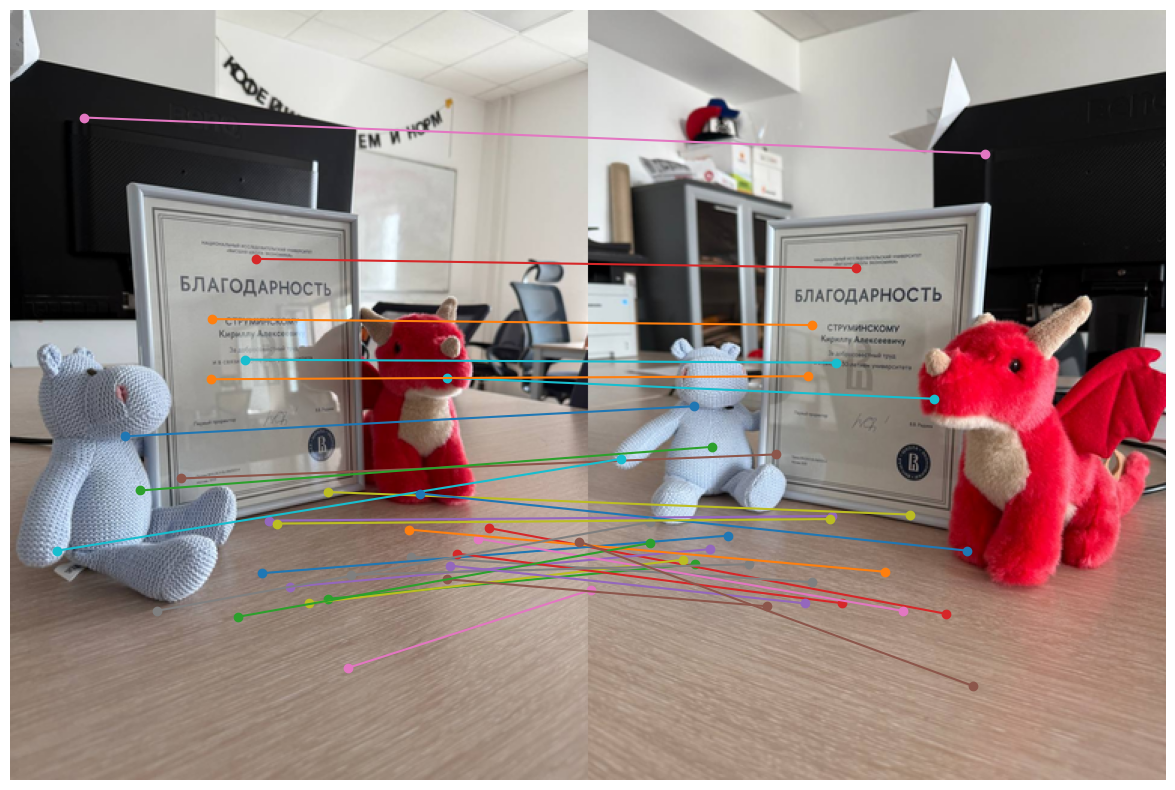

In [11]:
def plot_matches(ax, points_l, points_r, w):
    for point_l, point_r in zip(points_l, points_r):
        ax.plot([point_l[0], point_r[0] + w],
                [point_l[1], point_r[1]],
               marker='o')

sample_idx = torch.randperm(len(matches))[:30]
points_l  = matches[:, [1,0]][sample_idx]
points_r = matches[:, [3,2]][sample_idx]

fig, ax = plt.subplots(figsize=(17, 10))
concatenated_image = np.concatenate((img_left, img_right), axis=1)
ax.imshow(concatenated_image)
plot_matches(ax, points_l, points_r, W)
ax.axis('off')
plt.show()

### Recovering intrinsics

By definition, the pointmap $X^{1,1}$ is
expressed in $I^1$’s coordinate frame. It is therefore possible
to estimate the camera intrinsic parameters by solving a
simple optimization problem. We assume that the principal point is approximately centered and pixel are
squares:

$$K = \begin{bmatrix} f_1^* & 0 & \frac{W}{2} \\ 0 & f_1^* & \frac{H}{2} \\ 0 & 0 & 1  \end{bmatrix}$$

Hence only the focal $f_1^*$ remains to be estimated:

$$f_1^* = \underset{f_1}{argmin} \sum \limits_{i = 0}^W \sum \limits_{j = 0}^H C_{i, j}^{1, 1}||(i', j') - f_{1} \frac{( X^{1, 1}_{i, j, 0}, X^{1, 1}_{i, j, 1})}{X^{1, 1}_{i, j, 2}}||$$

where

$$X_{i, j}^{1, 1} = (X_{i, j, 0}^{1, 1}, X_{i, j, 1}^{1, 1}, X_{i, j, 2}^{1, 1}) = (x, y, z)$$

$$i' = i - \frac{W}{2} \quad j' = j - \frac{H}{2} $$

$$ f_{1} \frac{( X^{1, 1}_{i, j, 0}, X^{1, 1}_{i, j, 1})}{X^{1, 1}_{i, j, 2}} - \text{perspective projection of 3D point.}$$

Fast iterative solvers, e.g. based on the Weiszfeld algorithm, can find the optimal $f^*_1$ in a few iterations.

**Weiszfeld algorithm**

The geometric median of a discrete point set in a Euclidean space is the point minimizing the sum of the Euclidean distances to the sample points.

Given a set of point $\{\mathbf{x}_i\}_{i=0}^m$ with each $\mathbf{x}_i \in \mathbb{R}^{n}$, the geometric median is defined as the sum of the $L_2$ distances minimizer:

 $$ \underset{y \in \mathbb{R}^n}{\text{argmin}} \sum \limits_{i=1}^{m}|| x_{i}-y ||_{2}$$

 It has been shown that no explicit formula, nor an exact algorithm involving only arithmetic operations and kth roots, can exist in general for the geometric median. Therefore, only numerical or symbolic approximations to the solution of this problem are possible under this model of computation.

Weiszfeld's algorithm defines a set of weights that are inversely proportional to the distances from the current estimate to the sample points, and creates a new estimate that is the weighted average of the sample according to these weights. That is,

$${\displaystyle \left.y_{k+1}=\left(\sum _{i=1}^{m}{\frac {x_{i}}{||x_{i}-y_{k}||_2}}\right)\right/\left(\sum _{i=1}^{m}{\frac {1}{||x_{i}-y_{k}||_2}}\right).}$$

This method converges for almost all initial positions, but may fail to converge when one of its estimates falls on one of the given points.


In our case

$$
f_{k+1} = \frac{ \sum \limits_{i = 0}^W \sum \limits_{j = 0}^H \frac{C_{i, j} \langle \mathbf{t}_k, \mathbf{P}_{i, j} \rangle }{ \| \mathbf{t}_{i, j} - f_k \cdot \mathbf{P}_{i, j} \| } }
         { \sum \limits_{i = 0}^W \sum \limits_{j = 0}^H \frac{C_{i, j}\| \mathbf{P}_{i, j} \|^2 }{ \| \mathbf{t}_{i, j} - f_k \mathbf{P}_{i, j} \| } }
$$


where $\quad \mathbf{P}_{i, j} = \frac{( X^{1, 1}_{i, j, 0}, X^{1, 1}_{i, j, 1})}{X^{1, 1}_{i, j, 2}}, \quad \mathbf{t}_{i, j} = (i', j')$

In [12]:
def estimate_focal_weiszfeld(pts3d, conf, max_iter = 10, tol = 1e-6) -> float:
    H, W, _ = pts3d.shape

    j_coords, i_coords = torch.meshgrid(
        torch.arange(H, dtype=torch.float32, device=pts3d.device),
        torch.arange(W, dtype=torch.float32, device=pts3d.device),
        indexing='ij'
    )
    i_prime = i_coords - W / 2
    j_prime = j_coords - H / 2
    T = torch.stack((i_prime, j_prime), dim=-1).reshape(-1, 2)

    X = pts3d.reshape(-1, 3)
    valid = X[:, 2] > 1e-6
    P = torch.zeros_like(X[:, :2])
    P[valid] = X[valid, :2] / X[valid, 2:3]

    C = conf.reshape(-1)

    f = torch.tensor(1.0, dtype=torch.float32, device=pts3d.device)

    for _ in range(max_iter):
        proj = f * P
        diff = T - proj
        norms = torch.norm(diff, dim=1).clamp(min=1e-6)

        weighted_dot = torch.sum(C * torch.sum(T * P, dim=1) / norms)
        weighted_norm = torch.sum(C * torch.sum(P * P, dim=1) / norms)

        f_new = weighted_dot / weighted_norm

        if torch.abs(f_new - f) < tol:
            break

        f = f_new

    return f.item()


f1 = estimate_focal_weiszfeld(pred1['pts3d'][0], pred1['conf'][0])
camera_instinsics = np.array([[f1, 0, W / 2], [0, f1, H / 2], [0, 0, 1]])

print(f"f1 = {f1:.3f}\n")
print("Estimated camera1 intrinsics:\n\n", camera_instinsics)

f1 = 374.884

Estimated camera1 intrinsics:

 [[374.884   0.    192.   ]
 [  0.    374.884 256.   ]
 [  0.      0.      1.   ]]


To verify the focal length, we use a built-in function from the dust3r library, which returns the camera intrinsic matrix for the first image.

In [13]:
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

scene = global_aligner(output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)
loss = scene.compute_global_alignment(init="mst")

/content/dust3r/dust3r/cloud_opt/base_opt.py:299: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


 init edge (1*,0*) score=np.float64(19.059431076049805)
 init loss = 0.0010549236321821809
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals', 'im_conf.0', 'im_conf.1']


  0%|          | 0/300 [00:00<?, ?it/s]/content/dust3r/dust3r/cloud_opt/base_opt.py:389: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss)
100%|██████████| 300/300 [00:06<00:00, 44.21it/s, lr=0.01 loss=0.000795152]


In [14]:
print("Camera1 intrinsics:\n\n", scene.get_intrinsics()[1].detach().cpu().numpy())

Camera1 intrinsics:

 [[374.421   0.    192.   ]
 [  0.    374.421 256.   ]
 [  0.      0.      1.   ]]


It should be noted that the image size is reduced to $384 \times 512 = H \times W$. Therefore, we should scale the intrinsics by $\frac{W_0}{W}$, as mentioned [here](https://github.com/naver/dust3r/issues/8#issuecomment-1985960363).